<a href="https://colab.research.google.com/github/Pgiuliano8/COMS5790-NPL-Projects/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Pre-processing and other requirements**
You will need to preprocess the text with:
1) extract text in titles and abstracts from the covid datasets,
2) tokenize and stem words,
3) convert to lower case,
4) any processes that you think is proper.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
import json
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
animal_df = pd.read_csv("/content/drive/MyDrive/ColabNB/COMS5790/animal.tsv", sep='\t')
#title + abstract
animal = (animal_df['Title'].fillna('') + " " + animal_df['Abstract'].fillna('')).tolist()
animal_df

,ID,Title,Abstract
0,29059723,Whole-genome association and genome partitioni...,OBJECTIVE: The study was designed to perform a...
1,17582132,A genome scan for quantitative trait locus by ...,Genotype by environment interactions between m...
2,16089036,Fine mapping of porcine chromosome 6 QTL and L...,The leptin receptor gene (LEPR) is a candidate...
3,27165028,Identification of loci affecting teat number b...,OBJECTIVE: Three genome-wide association studi...
4,30250203,GWAS and eQTL analysis identifies a SNP associ...,"Residual feed intake (RFI), a measure of feed ..."
...,...,...,...
1103,33369226,Two co-inherited novel SNPs in the MC4R gene r...,Melanocortin-4 receptor (MC4R) gene plays a ke...
1104,33853519,A QTL for conformation of back and croup influ...,BACKGROUND: The back plays a vital role in hor...
1105,33808485,Polymorphisms at Myostatin Gene (MSTN) and the...,One hundred and eighty Anglo-Arabian horses ru...
1106,33584826,Genomic Correlations Between the Gaits of Youn...,Functional longevity is essential for the well...


In [37]:
with open('/content/drive/MyDrive/ColabNB/COMS5790/litcovid_sample_1000.json', 'r', encoding='utf-8') as f:
    litcovid_data = json.load(f)

covid = []
for doc in litcovid_data:
  text = []
  for passage in doc.get("passages", []):
    section_type = passage.get('infons', {}).get("section_type", "").upper()
    if section_type in ["TITLE", "ABSTRACT"]:
      text.append(passage.get("text", ""))
  if text:
    covid.append(" ".join(text))

In [38]:
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))
def pp(text):
    """lowercasing, tokenization, delete punctuation/stop-words and stemming."""
    # 1. Lowercase e Tokenization
    tokens = word_tokenize(text.lower())

    clean_tokens = []
    for token in tokens:
        # 2. Punctuation and Stopwords
        if token.isalpha() and token not in stop_words and len(token) > 1:
            # 3. Stemming
            stemmed_word = stemmer.stem(token)
            clean_tokens.append(stemmed_word)

    return " ".join(clean_tokens)

In [39]:
animal_clean = [pp(text) for text in animal]
covid_clean = [pp(text) for text in covid]
len(animal_clean), len(covid_clean)

(1108, 474)

## **TASK 1**:      words visualization
Use word cloud to visualize words in these two datasets separately. The figure should be 800*800, with white background color. You will need to generate two word-cloud images for each dataset:
1) use word frequency,
 2) use tf-idf.


In [40]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [41]:
#FUNCTIONS

def wc_frequency(text, title, filename):
  """create the Word Cloud with the frequency of the words"""
  wc = WordCloud(width=800, height=800, background_color='white').generate(text)
  wc.to_file(filename)

  plt.figure(figsize=(8, 8))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(title, fontsize=20, pad=20)
  plt.show()

def wc_tfidf(text, title, filename):
  """create the Word Cloud with the tf-idf of the words"""
  vectorizer = TfidfVectorizer()
  tfidf_matrix = vectorizer.fit_transform(text)

  tfidf_sum = np.array(tfidf_matrix.sum(axis=0)).flatten()
  word = vectorizer.get_feature_names_out()
  tfidf_dict = dict(zip(word, tfidf_sum))

  wc = WordCloud(width=800, height=800, background_color="white").generate_from_frequencies(tfidf_dict)
  wc.to_file(filename)

  plt.figure(figsize=(8, 8))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(title, fontsize=20, pad=20)
  plt.show()



In [42]:
animal_all = " ".join(animal_clean)
covid_all = " ".join(covid_clean)

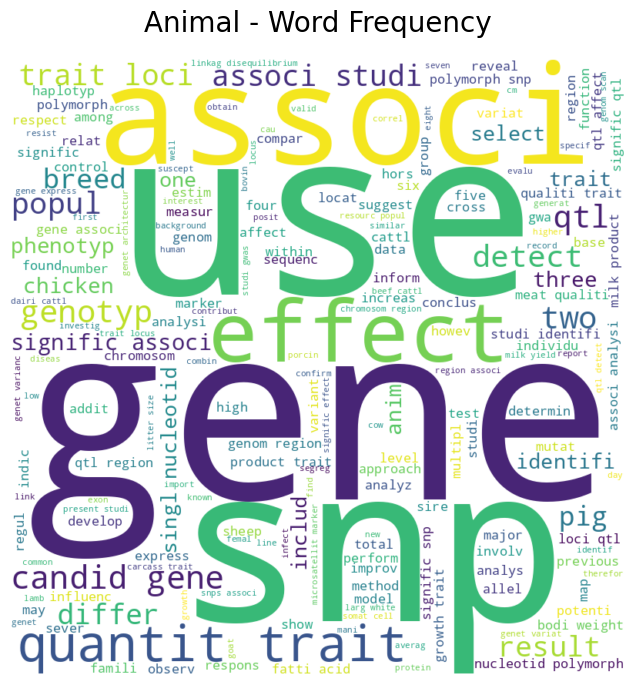

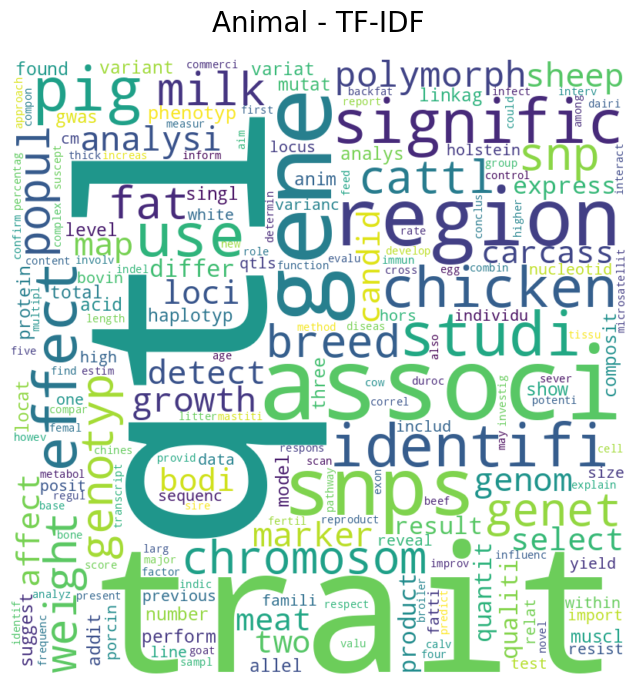

In [44]:
#Animal
wc_frequency(animal_all, "Animal - Word Frequency", "animal_freq.png")
wc_tfidf(animal_clean, "Animal - TF-IDF", "animal_tfidf.png")

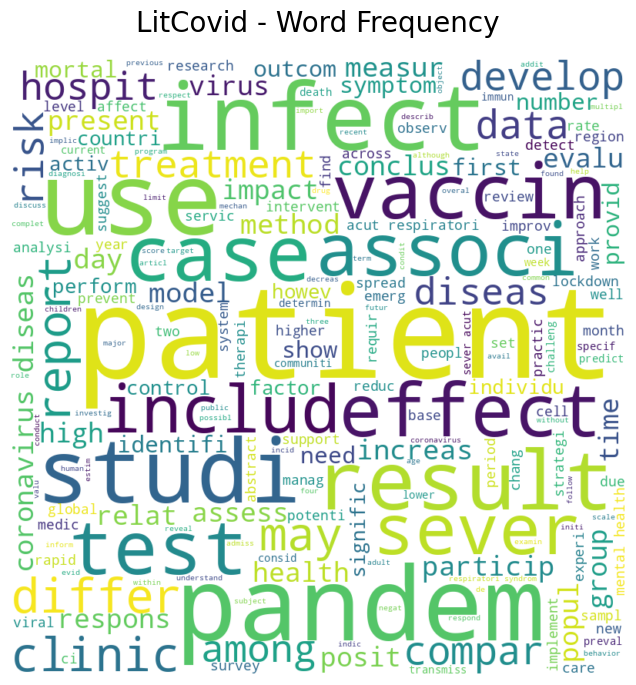

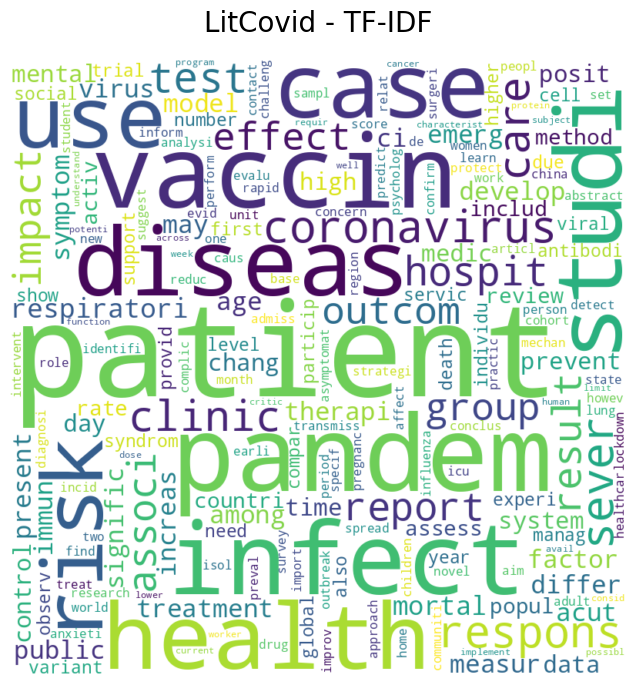

In [45]:
#LitCovid
wc_frequency(covid_all, "LitCovid - Word Frequency", "covid_freq.png")
wc_tfidf(covid_clean, "LitCovid - TF-IDF", "covid_tfidf.png")

# **Task 2**
Combine the text from the two datasets and train one embedding model (word2vec, Glove, etc.) with the following parameters:

`vector_size=100, min_count=10`

Visualize the embedding using t-SNE in 2D (you may use tf-idf to filter words if t-SNE runs too slow for you). Color the plot with three groups: words that are unique to animal science (red), words that are unique to covid research (blue), and common words (gray).


In [46]:
!pip install gensim

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

In [49]:
#list of token for Word2Vec
animal_tokens = [text.split() for text in animal_clean]
covid_tokens = [text.split() for text in covid_clean]
all_tokens = animal_tokens + covid_tokens

w2v_model = Word2Vec(sentences=all_tokens, vector_size=100, min_count=10, workers=4)
len(w2v_model.wv)

2271

In [50]:
animal_vocab_raw = set(word for text in animal_tokens for word in text)
covid_vocab_raw = set(word for text in covid_tokens for word in text)
vocab_w2v = set(w2v_model.wv.index_to_key)

common_words = animal_vocab_raw.intersection(covid_vocab_raw).intersection(vocab_w2v)
unique_animal = animal_vocab_raw.difference(covid_vocab_raw).intersection(vocab_w2v)
unique_covid = covid_vocab_raw.difference(animal_vocab_raw).intersection(vocab_w2v)



In [51]:
words = []
vectors = []
colors = []

for word in w2v_model.wv.index_to_key:
    words.append(word)
    vectors.append(w2v_model.wv[word])
    if word in unique_animal:
        colors.append('red')
    elif word in unique_covid:
        colors.append('blue')
    else:
        colors.append('gray')
vectors = np.array(vectors)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


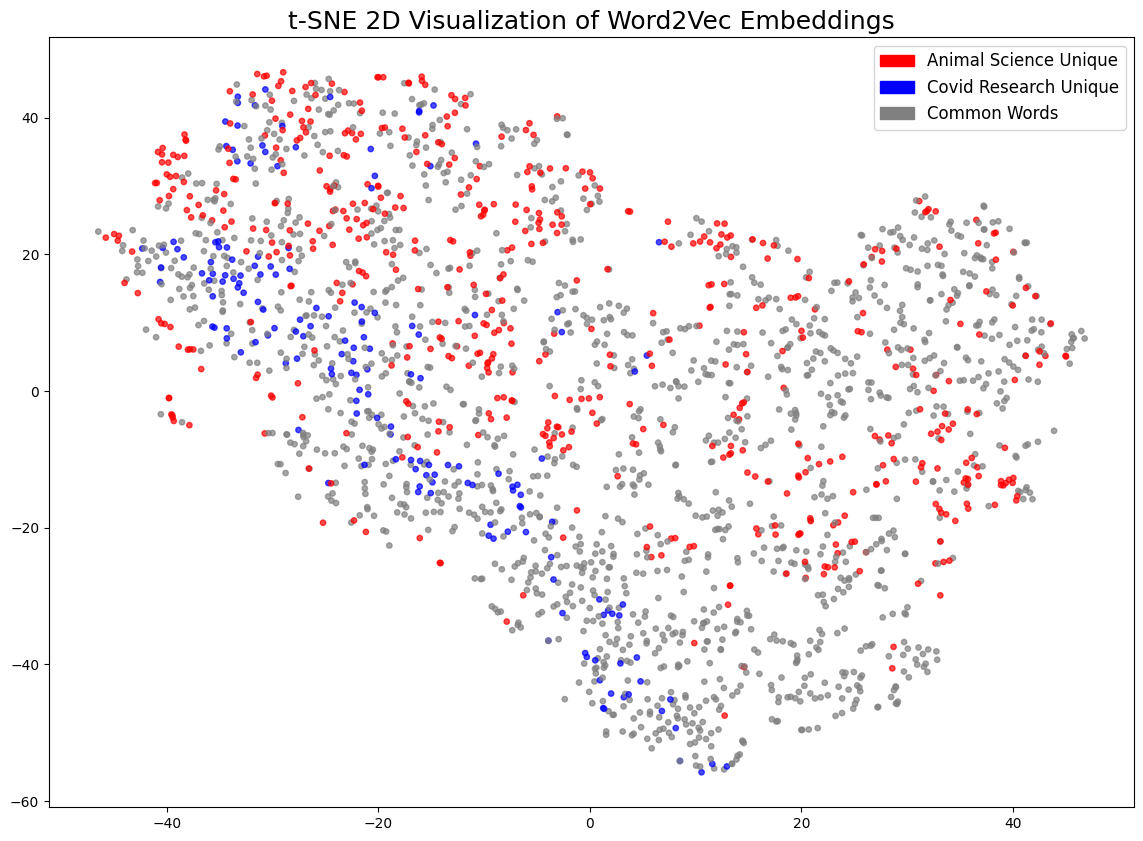

In [59]:
#T-SNE riduction and plot
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=colors, alpha=0.7, s=15)

#legend
red_patch = mpatches.Patch(color='red', label='Animal Science Unique')
blue_patch = mpatches.Patch(color='blue', label='Covid Research Unique')
gray_patch = mpatches.Patch(color='gray', label='Common Words')
plt.legend(handles=[red_patch, blue_patch, gray_patch], fontsize=12)

plt.title('t-SNE 2D Visualization of Word2Vec Embeddings', fontsize=18)
plt.savefig("tsne_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

## **Task 3**
Run a phrase mining method to annotate phrases in the two datasets.  You can be creative in phrase extraction algorithm design. The results should contain at least bi-grams and tri-grams.

One easy way for annotation is to use underscore (_) to join words in a phrase, as most tokenizers will not split words joint with underscore. But other ways of annotation are fine, too.
For example, original sentence:

“A genome scan for quantitative trait locus by environment interactions for production traits.”

After phrase extraction (the results can be different for different methods):

“A genome scan for quantitative_trait_locus by environment interactions for production_traits.”

**Then repeat Tasks 1.**


In [53]:
from gensim.models.phrases import Phrases, Phraser

In [69]:
bigram_phrases = Phrases(all_tokens, min_count=3, threshold=5)
bigram_model = Phraser(bigram_phrases)

trigram_phrases = Phrases(bigram_model[all_tokens], threshold=5)
trigram_model = Phraser(trigram_phrases)

In [70]:
#original lists of tokens to a new "united" version with underscore
animal_phrased_tokens = [trigram_model[bigram_model[doc]] for doc in animal_tokens]
covid_phrased_tokens = [trigram_model[bigram_model[doc]] for doc in covid_tokens]

#whole strings with Word Cloud
animal_phrased = [" ".join(doc) for doc in animal_phrased_tokens]
covid_phrased = [" ".join(doc) for doc in covid_phrased_tokens]

animal_text_phrased_all = " ".join(animal_phrased)
covid_text_phrased_all = " ".join(covid_phrased)

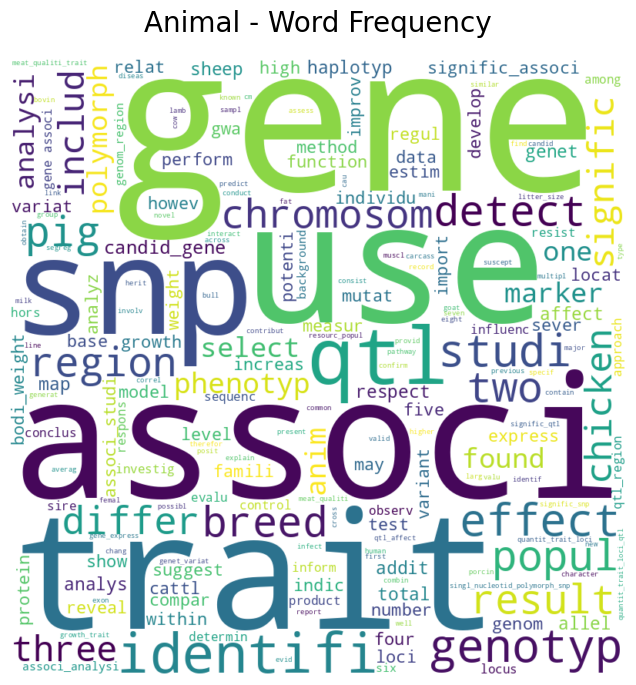

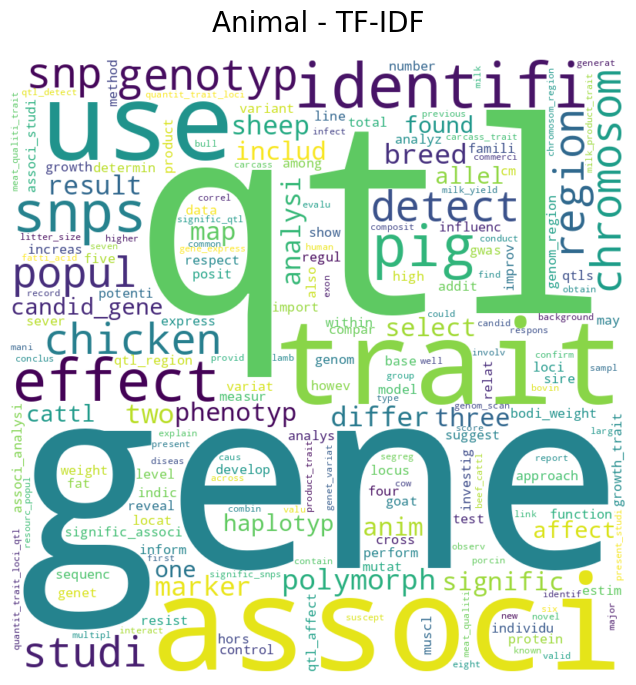

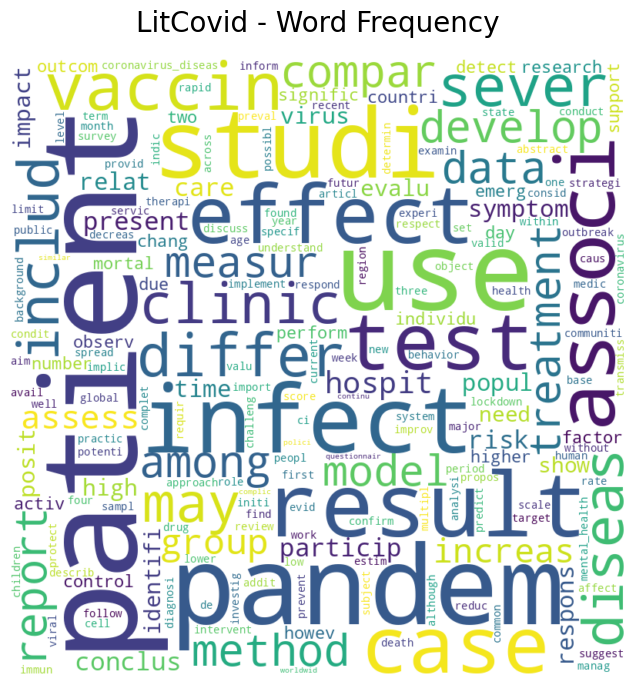

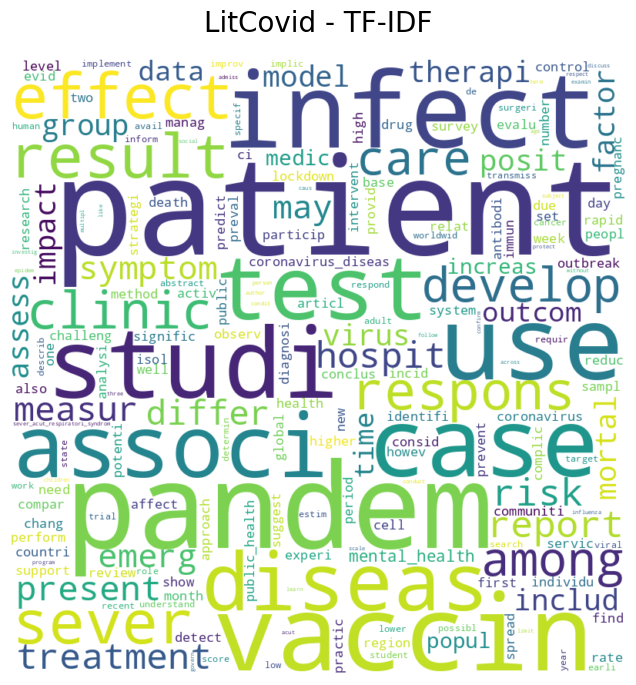

In [72]:
#TASK 1 with new tests
wc_frequency(animal_text_phrased_all, "Animal - Word Frequency", "animal_phrased_freq.png")
wc_tfidf(animal_phrased, "Animal - TF-IDF", "animal_phrased_tfidf.png")

wc_frequency(covid_text_phrased_all, "LitCovid - Word Frequency",  "litcovid_phrased_freq.png")
wc_tfidf(covid_phrased, "LitCovid - TF-IDF", "litcovid_phrased_tfidf.png")

In [75]:
#count of unique phrases and the top 5 most frequent phrases
from collections import Counter

def compute_statistics(phrased_tokens):
  """count of unique phrases and the top 5 most frequent phrases"""
  all_phrases = []

  for doc in phrased_tokens:
    for phrase in doc:
      if "_" in phrase:
        all_phrases.append(phrase)

  tot_phrases = len(all_phrases)
  unique_phrases = len(set(all_phrases))
  top5 = Counter(all_phrases).most_common(5)

  return tot_phrases, unique_phrases, top5


In [76]:
#ANIMAL
tot_animal_phrases, unique_animal_phrases, top5_animal = compute_statistics(animal_phrased_tokens)
print(f"Total count of phrases: {tot_animal_phrases}")
print(f"Count of unique phrases: {unique_animal_phrases}")
print("Top 5 most frequent phrases:")
for phrase, count in top5_animal:
    print(f"  - {phrase}: {count}")

Total count of phrases: 30591
Count of unique phrases: 2930
Top 5 most frequent phrases:
  - candid_gene: 401
  - signific_associ: 351
  - associ_studi: 328
  - bodi_weight: 214
  - genom_region: 205


In [77]:
#LITCOVID
tot_litcovid_phrases, unique_litcovid_phrases, top5_litcovid = compute_statistics(covid_phrased_tokens)
print(f"Total count of phrases: {tot_litcovid_phrases}")
print(f"Count of unique phrases: {unique_litcovid_phrases}")
print("Top 5 most frequent phrases:")
for phrase, count in top5_litcovid:
    print(f"  - {phrase}: {count}")

Total count of phrases: 5168
Count of unique phrases: 1092
Top 5 most frequent phrases:
  - coronavirus_diseas: 72
  - mental_health: 57
  - sever_acut_respiratori_syndrom: 43
  - public_health: 36
  - risk_factor: 35
